In [1]:
# auto reload modules
%load_ext autoreload
%autoreload 2

In [25]:
from cns.process.breakpoints import make_breaks
from cns.data_utils import load_COSMIC
import random
import numpy as np

cosmic_genes = load_COSMIC()
cosmic_genes.head()

_, start, end = make_breaks("arms")["chr3"]
gene_start, gene_end = cosmic_genes.query("gene == 'SOX2'")[["start", "end"]].values.tolist()[0]

In [26]:
# Initialize a list to store the ranges
ranges = []

reps = 10

# Repeat until 8 ranges are sampled
while len(ranges) < 6 * reps:
    # Generate a random range
    rand_start = random.randint(start, end)
    rand_end = random.randint(rand_start, end)

    # Check if the range contains gene_start and gene_end
    if rand_start <= gene_start and rand_end >= gene_end:
        # If it does, add it to the list
        ranges.append((rand_start, rand_end))

In [27]:
breaks = np.array(ranges).flatten()
breaks.sort()
split_ranges = []

for start, end in ranges:
    current_start = start

    for brk in breaks:
        if start < brk < end:
            split_ranges.append((current_start, brk))
            current_start = brk

    split_ranges.append((current_start, end))

In [28]:
import pandas as pd

# Count the occurrences of each pair
counts = pd.Series(split_ranges).value_counts().reset_index()

# Rename the columns
counts.columns = ['range', 'CN']

# Split the range into start and end
counts[['start', 'end']] = pd.DataFrame(counts['range'].tolist(), index=counts.index)

# Drop the 'range' column
counts = counts.drop('range', axis=1)

# Reorder the columns
counts = counts[['start', 'end', 'CN']].sort_values(by=['start'], ignore_index=True)
counts["CN"] = counts["CN"] / reps + 2
counts.head()

,start,end,CN
0,94841174,99613590,2.1
1,99613590,101033544,2.2
2,101033544,102009121,2.3
3,102009121,104161738,2.4
4,104161738,108101997,2.5


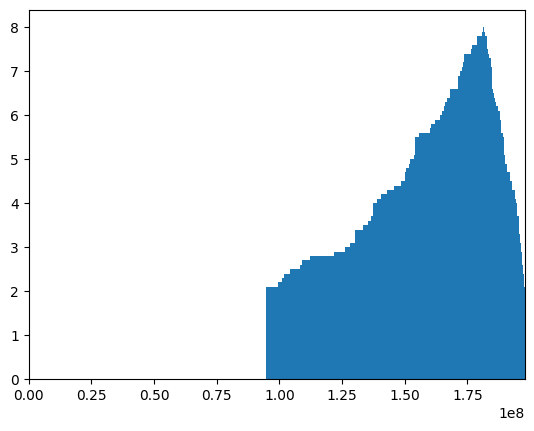

In [29]:
import matplotlib.pyplot as plt

# Calculate the widths of the bars
widths = counts['end'] - counts['start']

# Create a bar plot
plt.bar(x=counts['start'], height=counts['CN'], width=widths, align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))

# Display the plot
plt.show()

In [60]:
from cns.data_utils import load_merged_samples, load_merged_cns, get_cns_for_type

samples = load_merged_samples().query("type == 'LUSC'")
cns = load_merged_cns(samples)
data_chrom3 = cns.query("chrom == 'chr3'")

In [72]:
samples

,sex,type,chrom_count,chrom_missing,cover_bases_aut,cover_bases_sex,cover_bases_tot,cover_frac_aut,cover_frac_sex,cover_frac_tot,...,ane_major_cn_frac_aut,ane_minor_cn_frac_aut,ane_total_cn_frac_aut,ane_major_cn_sex,ane_minor_cn_sex,ane_total_cn_sex,ane_major_cn_frac_sex,ane_minor_cn_frac_sex,ane_total_cn_frac_sex,source
sample_id,,,,,,,,,,,,,,,,,,,,,
CRUK0090_SU_T1-R1,xy,LUSC,22.0,['chrX' 'chrY'],2667730394,0,2667730394,0.925963,0.000000,0.861760,...,0.964341,0.939087,0.578551,214644126,0,214644126,1.000000,0.000000,1.000000,TRACERx
CRUK0090_SU_T1-R2,xy,LUSC,22.0,['chrX' 'chrY'],2667730394,0,2667730394,0.925963,0.000000,0.861760,...,0.964346,0.938068,0.578544,214644126,0,214644126,1.000000,0.000000,1.000000,TRACERx
CRUK0076_SU_T1-R1,xy,LUSC,22.0,['chrX' 'chrY'],2622396892,0,2622396892,0.910228,0.000000,0.847116,...,0.840294,0.575726,0.515292,214644126,0,214644126,1.000000,0.000000,1.000000,TRACERx
CRUK0076_SU_T1-R2,xy,LUSC,22.0,['chrX' 'chrY'],2622396892,0,2622396892,0.910228,0.000000,0.847116,...,0.853892,0.567232,0.585293,214644126,0,214644126,1.000000,0.000000,1.000000,TRACERx
CRUK0076_SU_T1-R3,xy,LUSC,22.0,['chrX' 'chrY'],2622396892,0,2622396892,0.910228,0.000000,0.847116,...,0.832572,0.572272,0.512868,214644126,0,214644126,1.000000,0.000000,1.000000,TRACERx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-O2-A52V,xx,LUSC,23.0,[],2793336083,155061055,2948397138,0.969561,0.998651,0.971048,...,0.085290,0.329921,0.400992,0,21885433,21885433,0.000000,0.140950,0.140950,TCGA
TCGA-O2-A52W,xy,LUSC,23.0,['chrY'],2782101908,155031430,2937133338,0.965661,0.722272,0.948785,...,0.929710,0.698613,0.596537,214644126,324092,214644126,1.000000,0.001510,1.000000,TCGA
TCGA-O2-A5IB,xx,LUSC,23.0,[],2752347052,155063383,2907410435,0.955333,0.998666,0.957549,...,0.161537,0.291404,0.421903,20799475,0,20799475,0.133956,0.000000,0.133956,TCGA


In [65]:
from cns.process.breakpoints import get_breaks
data_breaks = get_breaks(data_chrom3)

In [66]:
from cns.process.binning import bin_by_breaks

binned_data = bin_by_breaks(data_chrom3, { "chr3": breaks}, print_progress=True)

In [67]:
from cns.process.binning import group_bins, add_cns_loc

groups = group_bins(add_cns_loc(binned_data))

ValueError: Cannot set a DataFrame with multiple columns to the single column cum_mid

In [ ]:
groups

,cum_mid,chrom,start,end,mid,length,major_cn,minor_cn,total_cn
0,589677376,chr3,94841174,99613590,97227382,4772416,1.689007,1.137936,2.826942
1,592773561,chr3,99613590,101033544,100323567,1419954,1.685667,1.136923,2.822590
2,593971326,chr3,101033544,102009121,101521332,975577,1.688578,1.138840,2.827418
3,595535423,chr3,102009121,104161738,103085429,2152617,1.690655,1.137425,2.828080
4,598581861,chr3,104161738,108101997,106131867,3940259,1.700286,1.138500,2.838786
...,...,...,...,...,...,...,...,...,...
114,689661944,chr3,197105420,197318481,197211950,213061,1.997477,1.163120,3.160597
115,689884398,chr3,197318481,197550327,197434404,231846,1.993357,1.162624,3.155981
116,690021718,chr3,197550327,197593121,197571724,42794,1.992522,1.162537,3.155060
117,690071538,chr3,197593121,197649968,197621544,56847,1.992763,1.162655,3.155418


(0.0, 197787344.0)

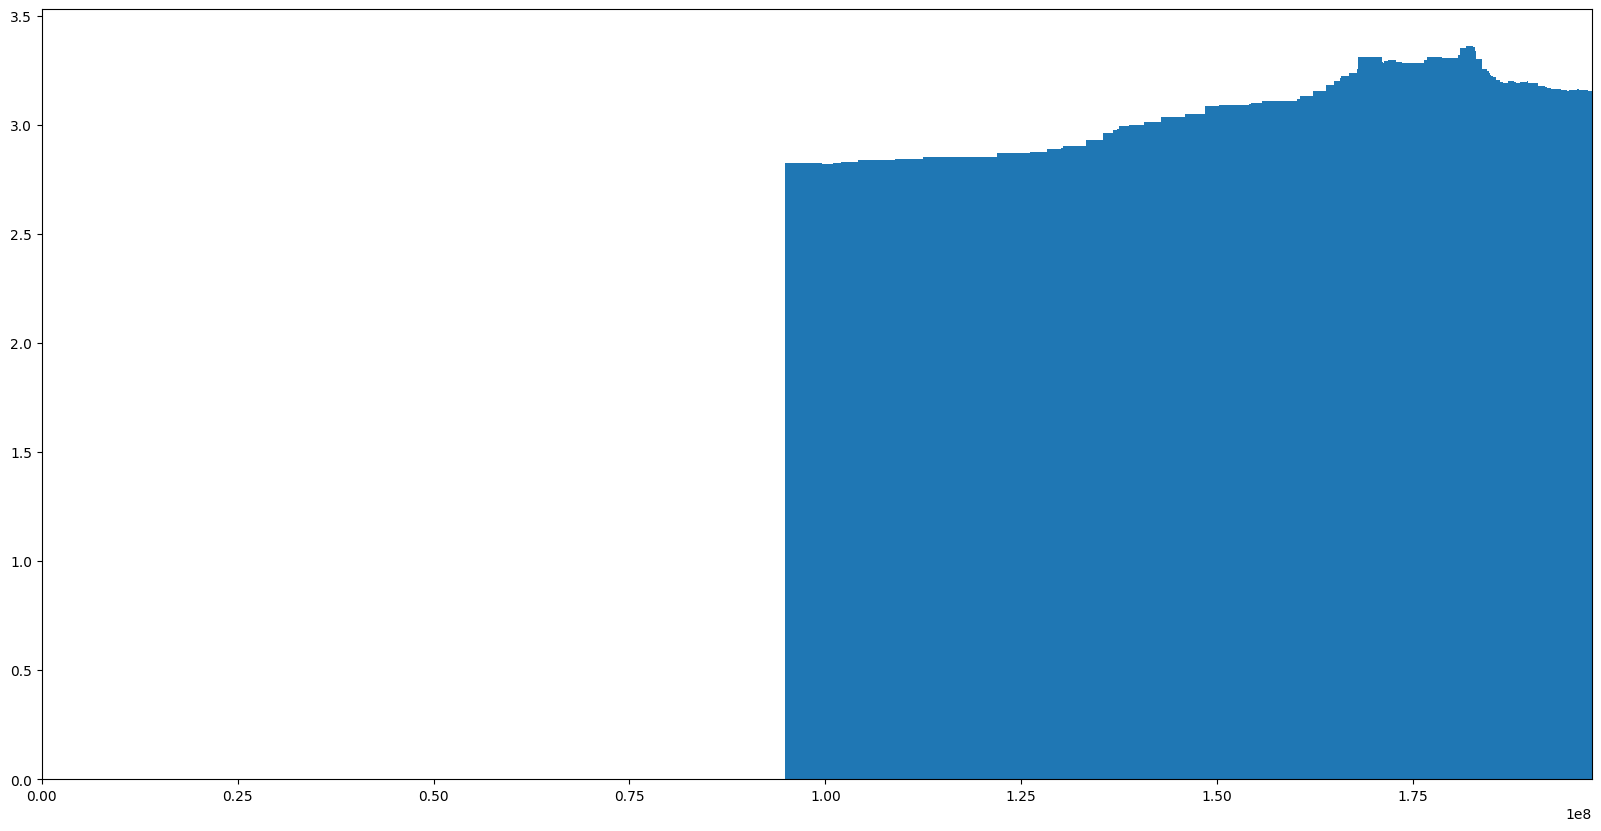

In [ ]:
# bar plot groups 
fig, ax = plt.subplots(figsize=(20, 10))

# Create a bar plot
plt.bar(x=groups['start'], height=groups['total_cn'], width=(groups['end'] - groups['start']), align='edge')

# Set the x-axis start to 0
plt.xlim(0, max(counts['end']))
